In [10]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import neurokit2 as nk
import spikeinterface.extractors as se
import glob
import os
import h5py
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
from scipy.signal import find_peaks
from collections import defaultdict
import math


In [11]:
H5_DIRS = {
    # --- RI1 ---
    "RI1_day1": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs",
    "RI1_day2": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs",

    # --- RI2 post ---
    "RI2_post_d1": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs",
    "RI2_post_d2": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2\h5_outputs",
}


In [12]:
all_files = []

for folder in H5_DIRS.values():
    for fname in os.listdir(folder):
        if fname.endswith(".h5"):
            all_files.append(os.path.join(folder, fname))

print("Total files:", len(all_files))


Total files: 94


Helper functions 

In [13]:
def get_sniff_respiratory_rate(
    signal,
    time,
    sniff_start,
    sniff_end,
    sampling_rate=100,
    max_rate_hz=12
):
    """
    Compute average respiration/sniff rate using inter-breath intervals (IBI).
    
    Returns:
        avg_rate_hz (float) or np.nan
    """

    # -----------------------------
    # Mask window
    # -----------------------------
    sniff_mask = (time >= sniff_start) & (time < sniff_end)

    if sniff_mask.sum() < sampling_rate:  # <1 s of data
        return np.nan

    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # -----------------------------
    # Pre-clean for peak detection
    # -----------------------------
    signal_sniff = signal_sniff - np.mean(signal_sniff)

    # -----------------------------
    # Peak detection
    # -----------------------------
    min_ibi = 1.0 / max_rate_hz
    min_distance = int(min_ibi * sampling_rate)

    peaks, _ = find_peaks(
        signal_sniff,
        distance=min_distance
    )

    if len(peaks) < 2:
        return np.nan

    # -----------------------------
    # IBI and rate
    # -----------------------------
    peak_times = time_sniff[peaks]
    ibi = np.diff(peak_times)          # seconds
    inst_rate = 1.0 / ibi              # Hz

    return np.mean(inst_rate)


In [14]:
def load_resp_simple(h5_file, target_rate=100, trodes_rate=20000):
    import h5py
    import numpy as np
    from scipy.signal import butter, filtfilt, resample_poly
    import neurokit2 as nk

    with h5py.File(h5_file, 'r') as f:
        resp_key = [k for k in f['analog'].keys() if "Ain1" in k][0]
        resp = f['analog'][resp_key][()]['voltage'].astype(float)

    # Time relative to recording start
    t = np.arange(len(resp)) / trodes_rate

    # Clean
    resp -= np.median(resp)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # Low-pass + downsample
    nyq = trodes_rate / 2
    b, a = butter(4, (target_rate / 2) / nyq, btype="low")
    resp_filt = filtfilt(b, a, resp)

    down = int(trodes_rate // target_rate)
    resp_ds = resample_poly(resp_filt, up=1, down=down)
    t_ds = t[::down]

    # Bandpass
    resp_clean = nk.signal_filter(
        resp_ds,
        lowcut=0.1,
        highcut=20,
        sampling_rate=target_rate,
        order=2
    )

    return resp_clean, t_ds


Define social time 

In [15]:
SOCIAL_START = 60
SOCIAL_END   = 240


In [16]:
h5_file = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\1_1_RI1_f1_d_on_20260111_164638.h5"


In [17]:
rsp, t = load_resp_simple(h5_file)

social_rate = get_sniff_respiratory_rate(
    signal=rsp,
    time=t,
    sniff_start=SOCIAL_START,
    sniff_end=SOCIAL_END,
    sampling_rate=100
)

print("Social respiration rate (Hz):", social_rate)


Social respiration rate (Hz): 9.152318103834027


In [9]:
rows = []

for h5_file in all_files:
    
    fname = os.path.basename(h5_file)
    parts = fname.split("_")
    
    subject = "_".join(parts[0:2])
    condition = parts[2]
    laser = "ON" if "_on_" in fname else "OFF"
    
    rsp, t = load_resp_simple(h5_file)
    
    rate = get_sniff_respiratory_rate(
        signal=rsp,
        time=t,
        sniff_start=SOCIAL_START,
        sniff_end=SOCIAL_END,
        sampling_rate=100
    )
    
    rows.append({
        "Subject": subject,
        "Condition": condition,
        "Laser": laser,
        "RespRate": rate,
        "File": fname
    })

df_resp = pd.DataFrame(rows)

print("df_resp rebuilt.")
print("Subjects:", df_resp["Subject"].nunique())


df_resp rebuilt.
Subjects: 24


In [18]:
df_resp

,Subject,Condition,Laser,RespRate,File
0,1_1,RI1,ON,9.152318,1_1_RI1_f1_d_on_20260111_164638.h5
1,1_2,RI1,OFF,10.288113,1_2_RI1_f2_f_off_20260109_165330.h5
2,1_3,RI1,OFF,8.591796,1_3_RI1_f1_c_off_20260110_130254.h5
3,2_1,RI1,ON,9.249470,2_1_RI1_f2_h_on_20260110_145355.h5
4,2_2,RI1,OFF,8.654789,2_2_RI1_f1_b_off_20260109_150435.h5
...,...,...,...,...,...
89,7_3,RI2,ON,7.048291,7_3_RI2_m1_j_on_20260120_153051.h5
90,8_1,RI2,ON,6.274820,8_1_RI2_m2_n_on_20260120_132851.h5
91,8_2,RI2,OFF,7.554380,8_2_RI2_m1_l_off_20260120_171457.h5
92,8_3,RI2,ON,4.903191,8_3_RI2_m2_m_on_20260120_162340.h5


In [42]:
qc_metrics = []

for h5_file in all_files:
    
    rsp, t = load_resp_simple(h5_file)
    
    qc_metrics.append({
        "file": os.path.basename(h5_file),
        "std": np.std(rsp),
        "range": np.max(rsp) - np.min(rsp),
        "mean": np.mean(rsp)
    })

qc_df = pd.DataFrame(qc_metrics)

print("QC dataframe rebuilt.")
print(qc_df.head())


QC dataframe rebuilt.
                                  file         std        range      mean
0   1_1_RI1_f1_d_on_20260111_164638.h5  398.290569  4448.892152 -0.529422
1  1_2_RI1_f2_f_off_20260109_165330.h5  326.210282  2716.663758  0.307675
2  1_3_RI1_f1_c_off_20260110_130254.h5  277.362850  2673.364308  1.232536
3   2_1_RI1_f2_h_on_20260110_145355.h5  250.412452  2576.901473  1.841883
4  2_2_RI1_f1_b_off_20260109_150435.h5  428.592140  3936.356729 -0.198125


In [43]:
bad_files = qc_df[qc_df["std"] < 20]["file"]
bad_subjects = set(["_".join(f.split("_")[:2]) for f in bad_files])

df_resp_clean = df_resp[~df_resp["Subject"].isin(bad_subjects)].copy()

print("Subjects removed:", bad_subjects)
print("Remaining subjects:", df_resp_clean["Subject"].nunique())

Subjects removed: {'2_3', '6_3', '5_1', '8_1', '5_2', '6_2', '4_1', '5_3'}
Remaining subjects: 16


In [56]:
subject_counts = defaultdict(lambda: {"on": 0, "off": 0})

for path in all_files:
    fname = os.path.basename(path)
    subject = "_".join(fname.split("_")[0:2])  # cage_mouse
    
    if "_on_" in fname:
        subject_counts[subject]["on"] += 1
    elif "_off_" in fname:
        subject_counts[subject]["off"] += 1

for subj, counts in subject_counts.items():
    if counts["on"] != counts["off"]:
        print(f"\nSubject mismatch: {subj}")
        print("ON:", counts["on"])
        print("OFF:", counts["off"])


In [59]:
# Build structured list
structured_files = []

for item in all_files:
    
    h5_file = item["path"] if isinstance(item, dict) else item
    fname = os.path.basename(h5_file)
    
    parts = fname.split("_")
    subject = "_".join(parts[0:2])
    condition = parts[2]
    stim = parts[4]
    laser = "ON" if "_on_" in fname else "OFF"
    
    structured_files.append({
        "path": h5_file,
        "subject": subject,
        "condition": condition,
        "stim": stim,
        "laser": laser
    })

# Sort by subject, condition, stim, and laser (OFF first)
structured_files = sorted(
    structured_files,
    key=lambda x: (x["subject"], x["condition"], x["stim"], x["laser"] == "ON")
)


In [60]:
batch_size = 12

for batch_idx, start in enumerate(range(0, len(structured_files), batch_size)):
    
    batch = structured_files[start:start+batch_size]
    
    fig = plt.figure(figsize=(14, 10))
    
    for i, entry in enumerate(batch):
        
        rsp, t = load_resp_simple(entry["path"])
        
        color = "blue" if entry["laser"] == "ON" else "black"
        alpha = 0.4 if entry["condition"] == "RI2" else 1.0
        
        plt.subplot(4, 3, i+1)
        plt.plot(t, rsp, color=color, linewidth=0.5, alpha=alpha)
        
        plt.title(
            f"{entry['subject']} {entry['condition']} {entry['stim']} {entry['laser']}",
            fontsize=8
        )
        
        plt.xticks([])
        plt.yticks([])
    
    plt.tight_layout()
    
    # ---- SAVE ----
    save_path = os.path.join(qc_output_dir, f"QC_batch_{batch_idx+1}.png")
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    
    print("Saved:", save_path)
    
    plt.close(fig)



Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_1.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_2.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_3.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_4.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_5.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_6.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_7.png
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\QC_batch_8.png


In [47]:
on_files = [f for f in all_files if "_on_" in f]
off_files = [f for f in all_files if "_off_" in f]

print("ON files:", len(on_files))
print("OFF files:", len(off_files))


ON files: 47
OFF files: 47


In [64]:
on_subjects = sorted([os.path.basename(f).split("_")[0] + "_" + os.path.basename(f).split("_")[1] 
                      for f in on_files])

off_subjects = sorted([os.path.basename(f).split("_")[0] + "_" + os.path.basename(f).split("_")[1] 
                       for f in off_files])

print("Missing OFF:", set(on_subjects) - set(off_subjects))
print("Missing ON:", set(off_subjects) - set(on_subjects))


Missing OFF: set()
Missing ON: set()


Total files: 94


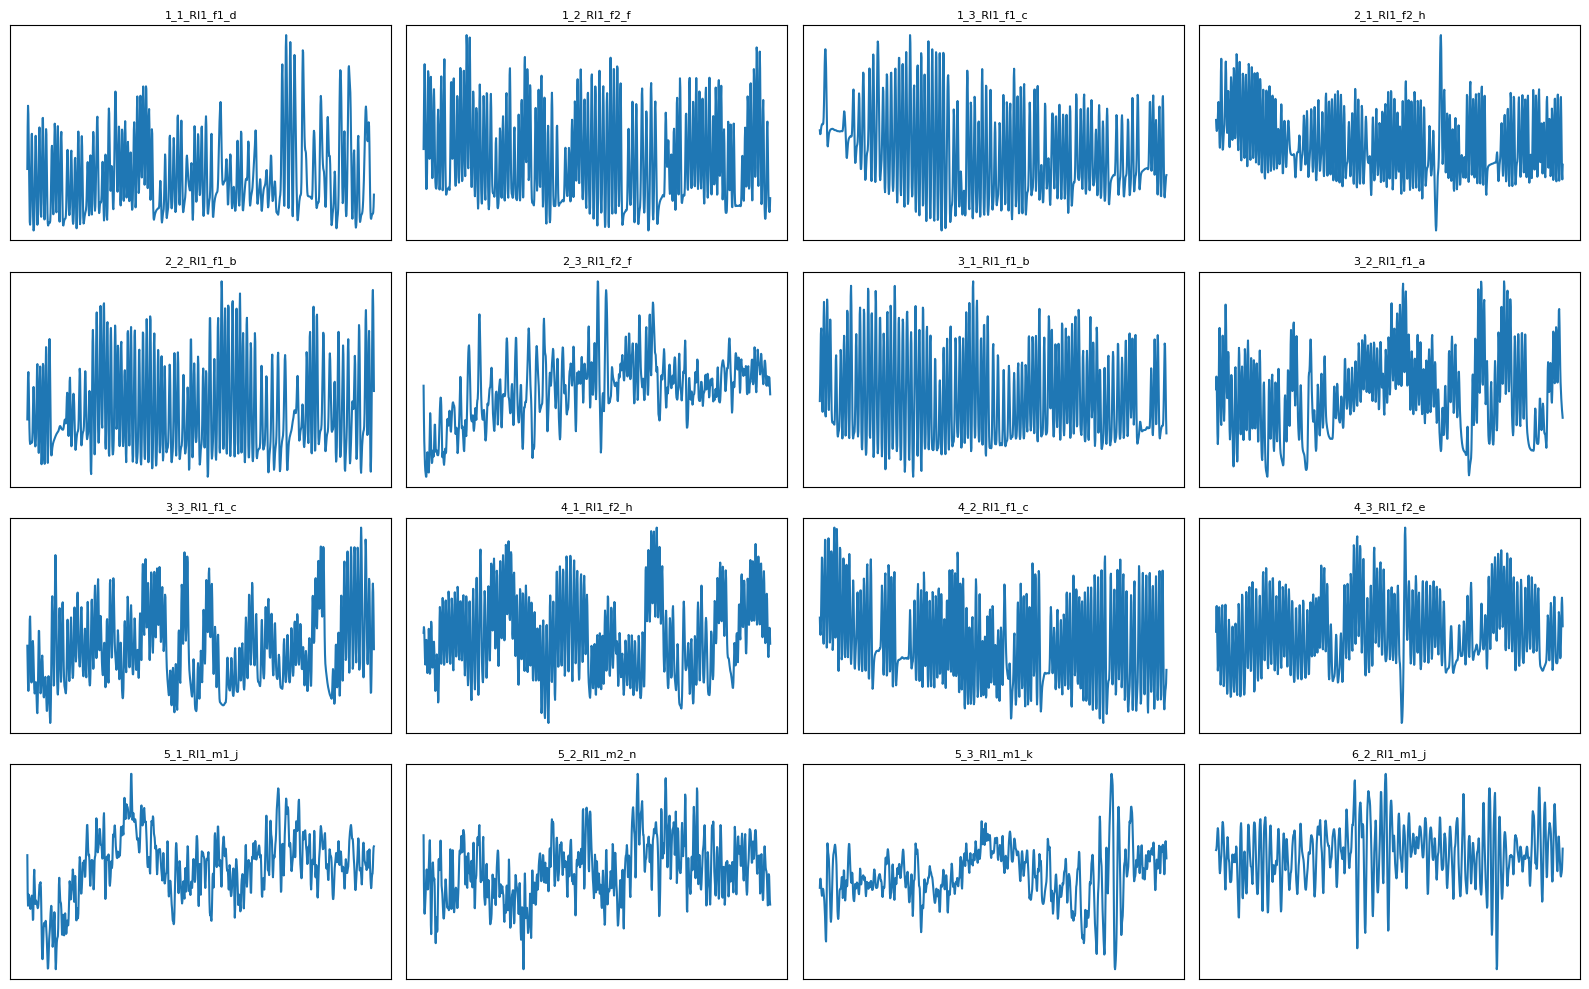

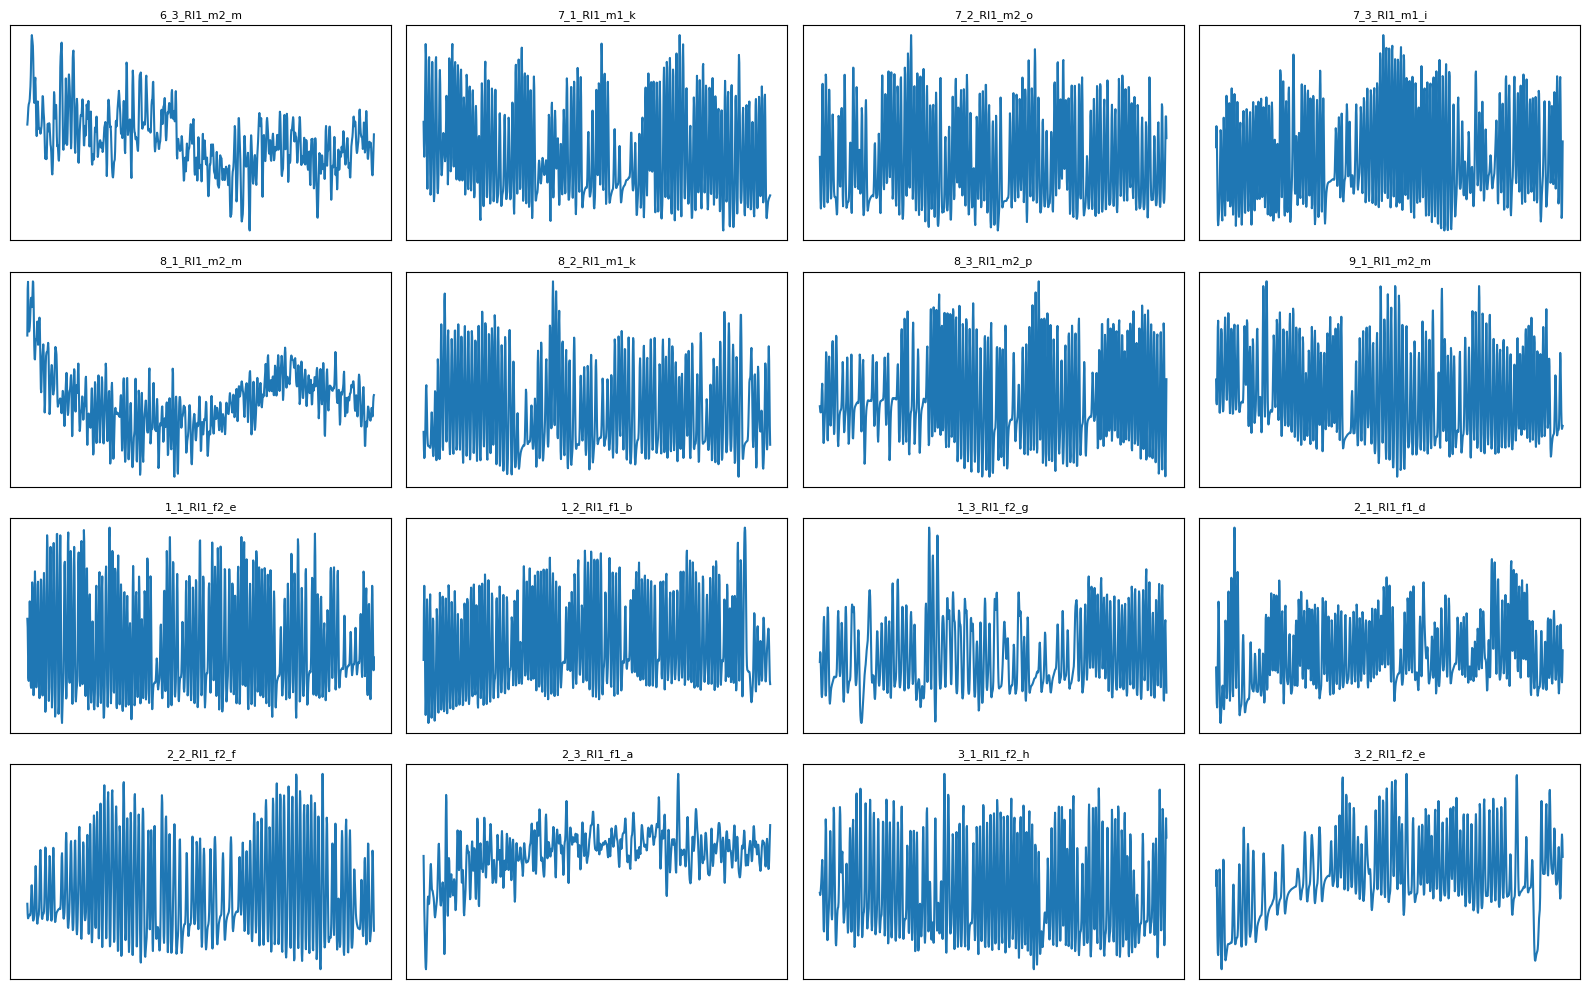

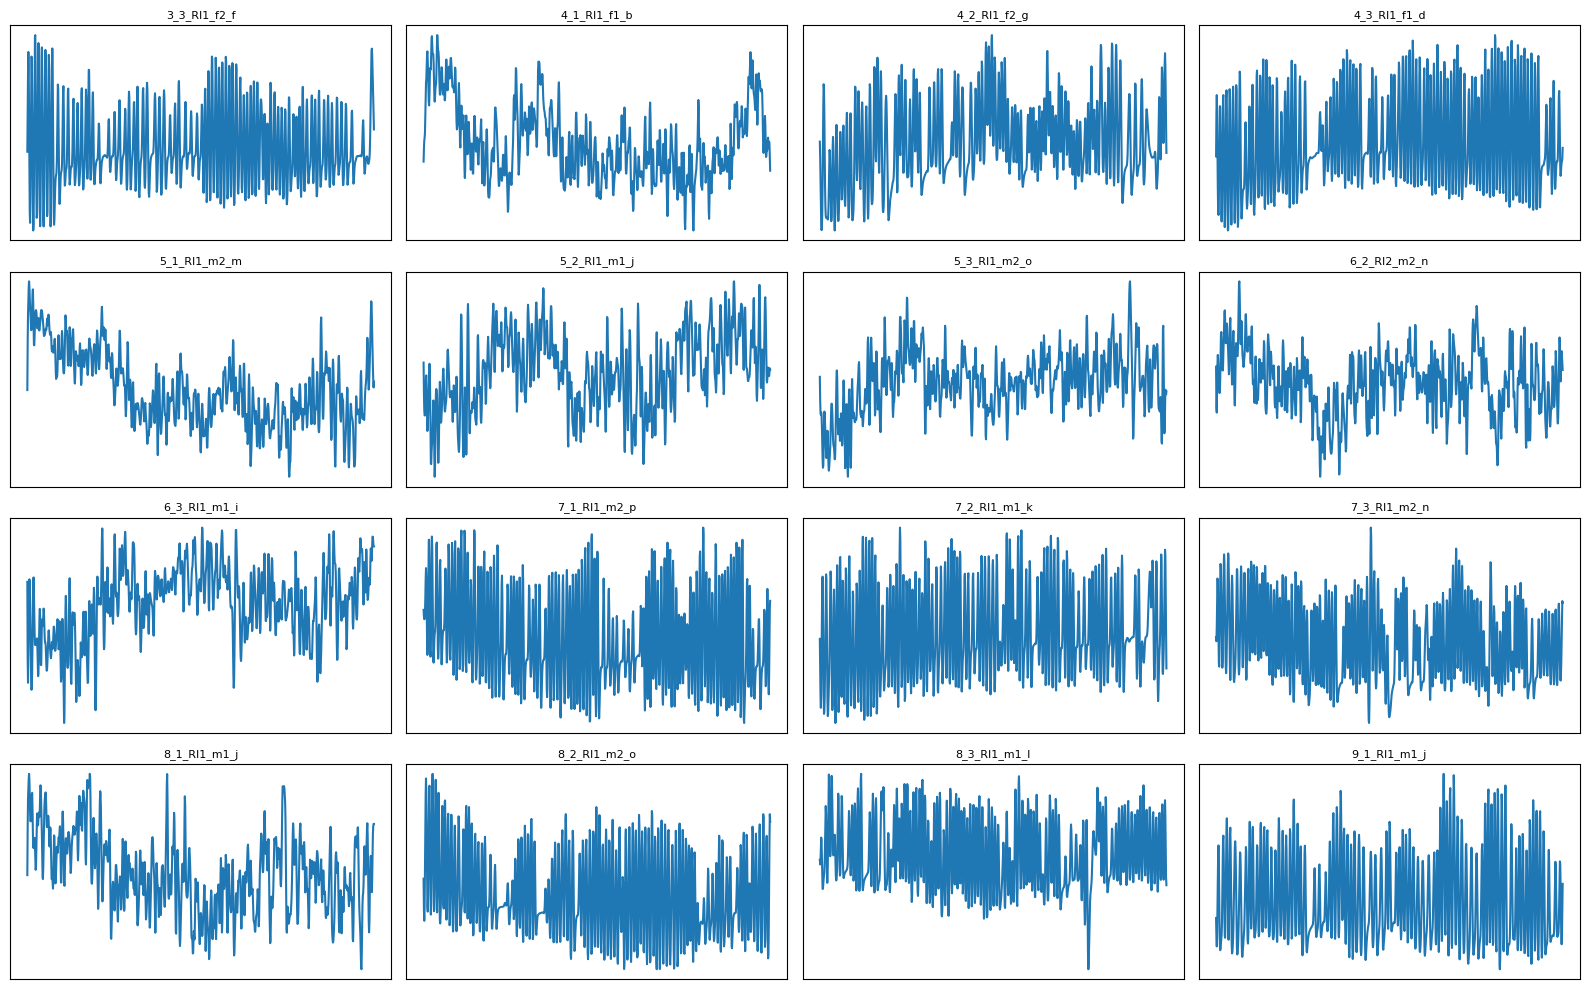

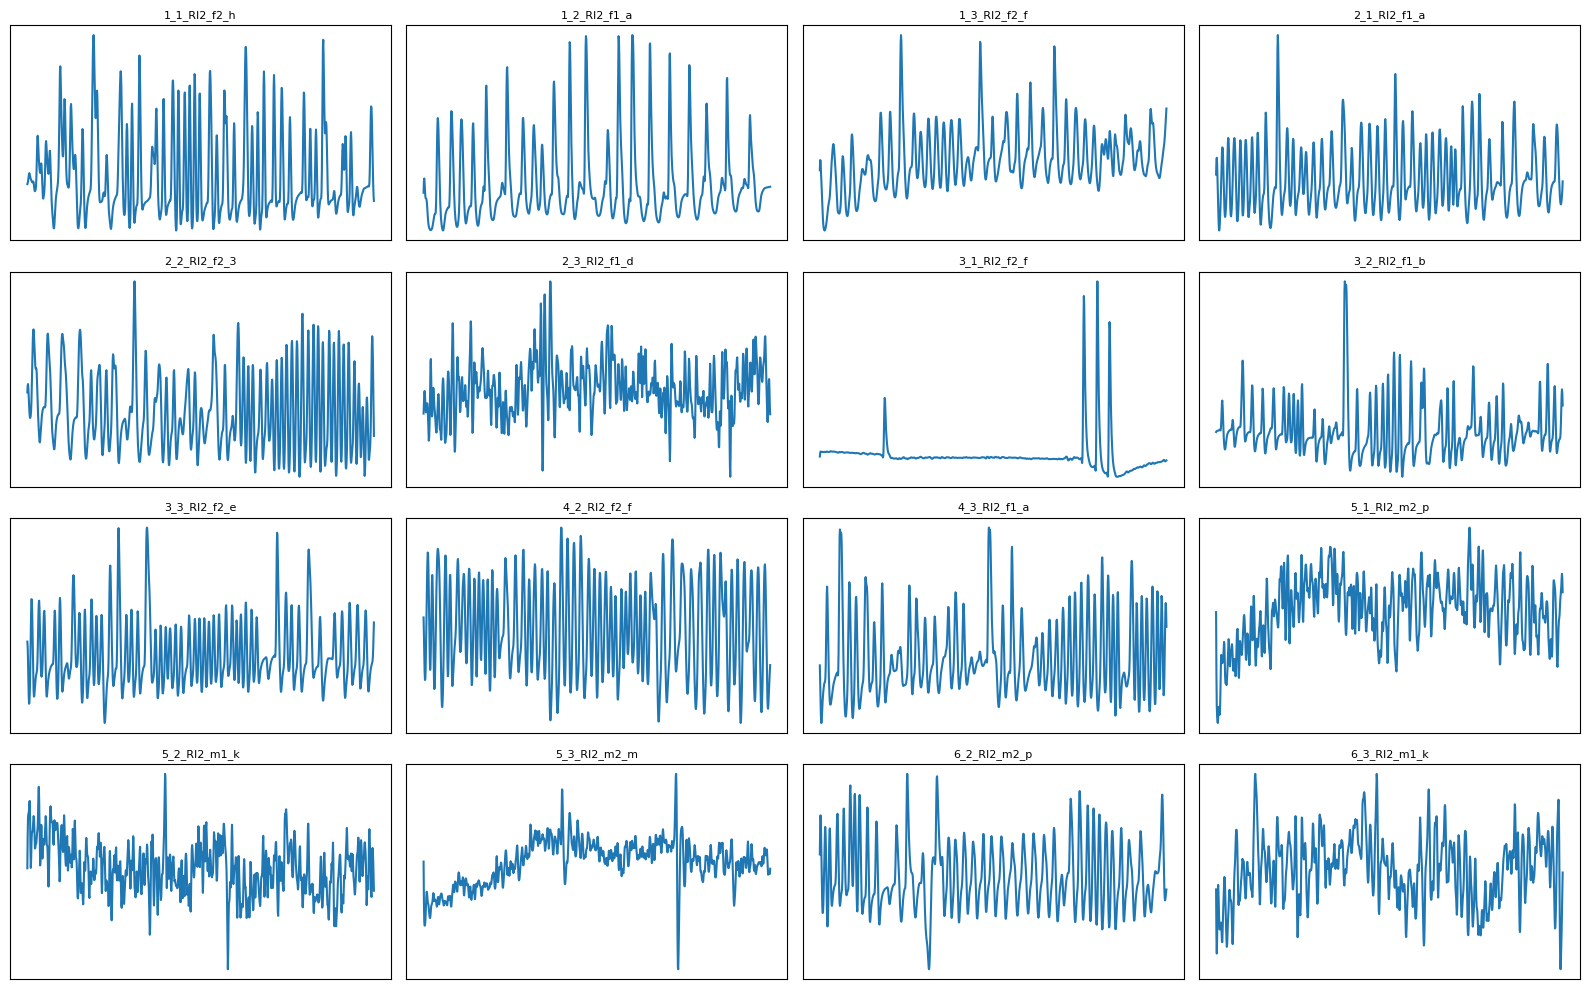

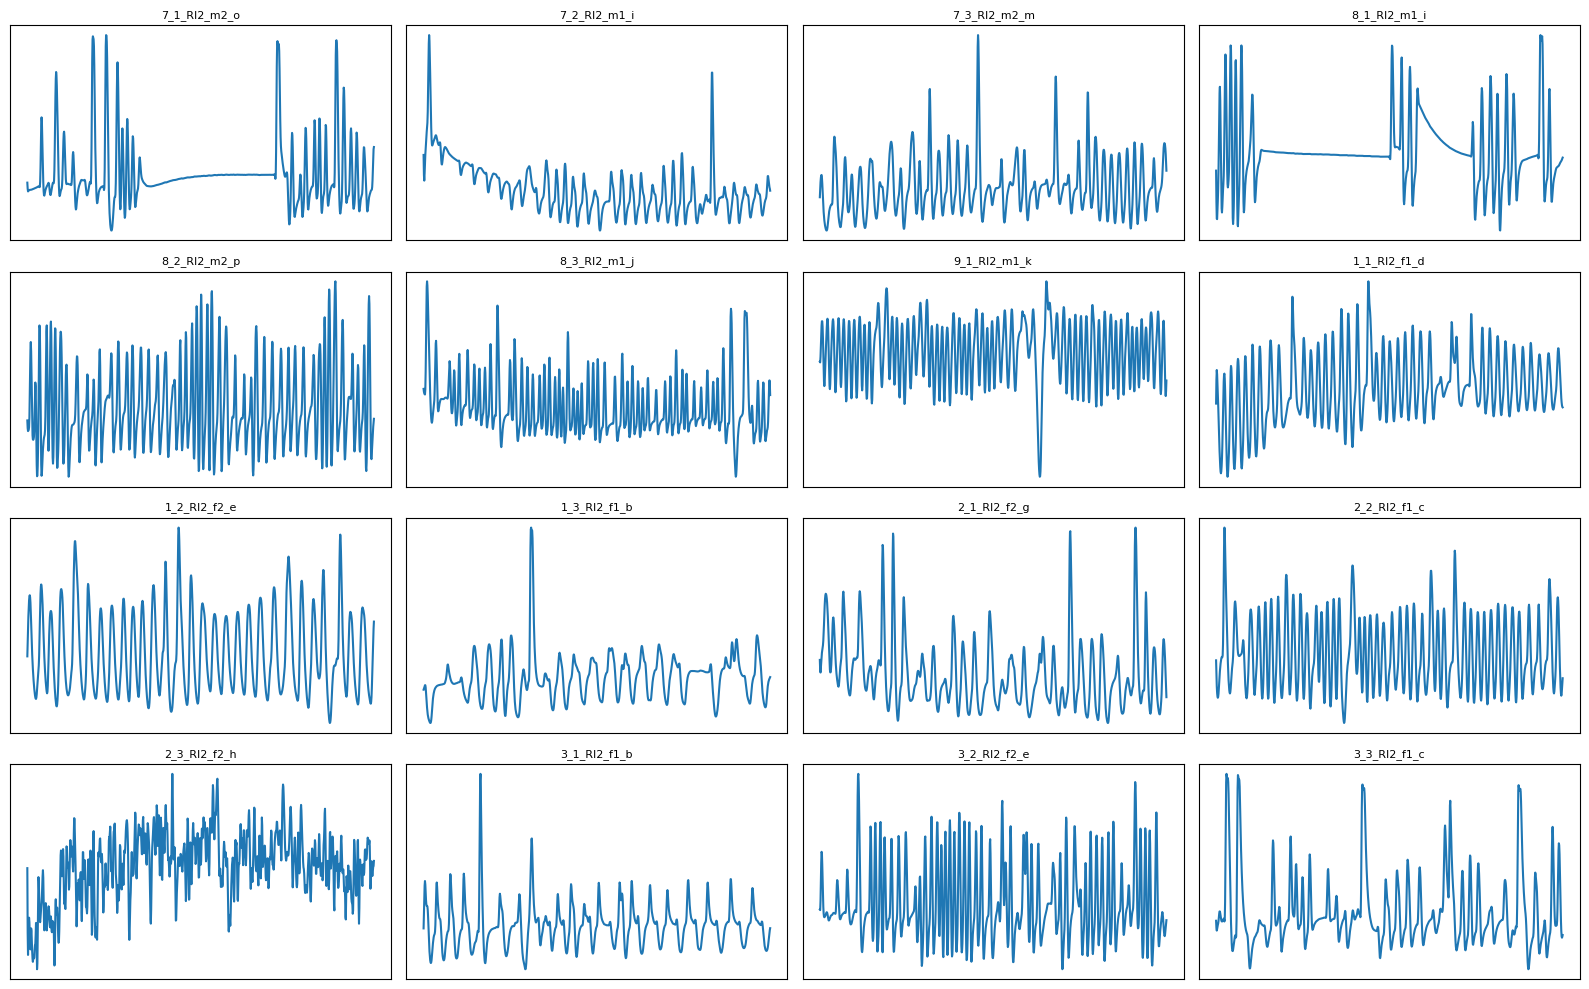

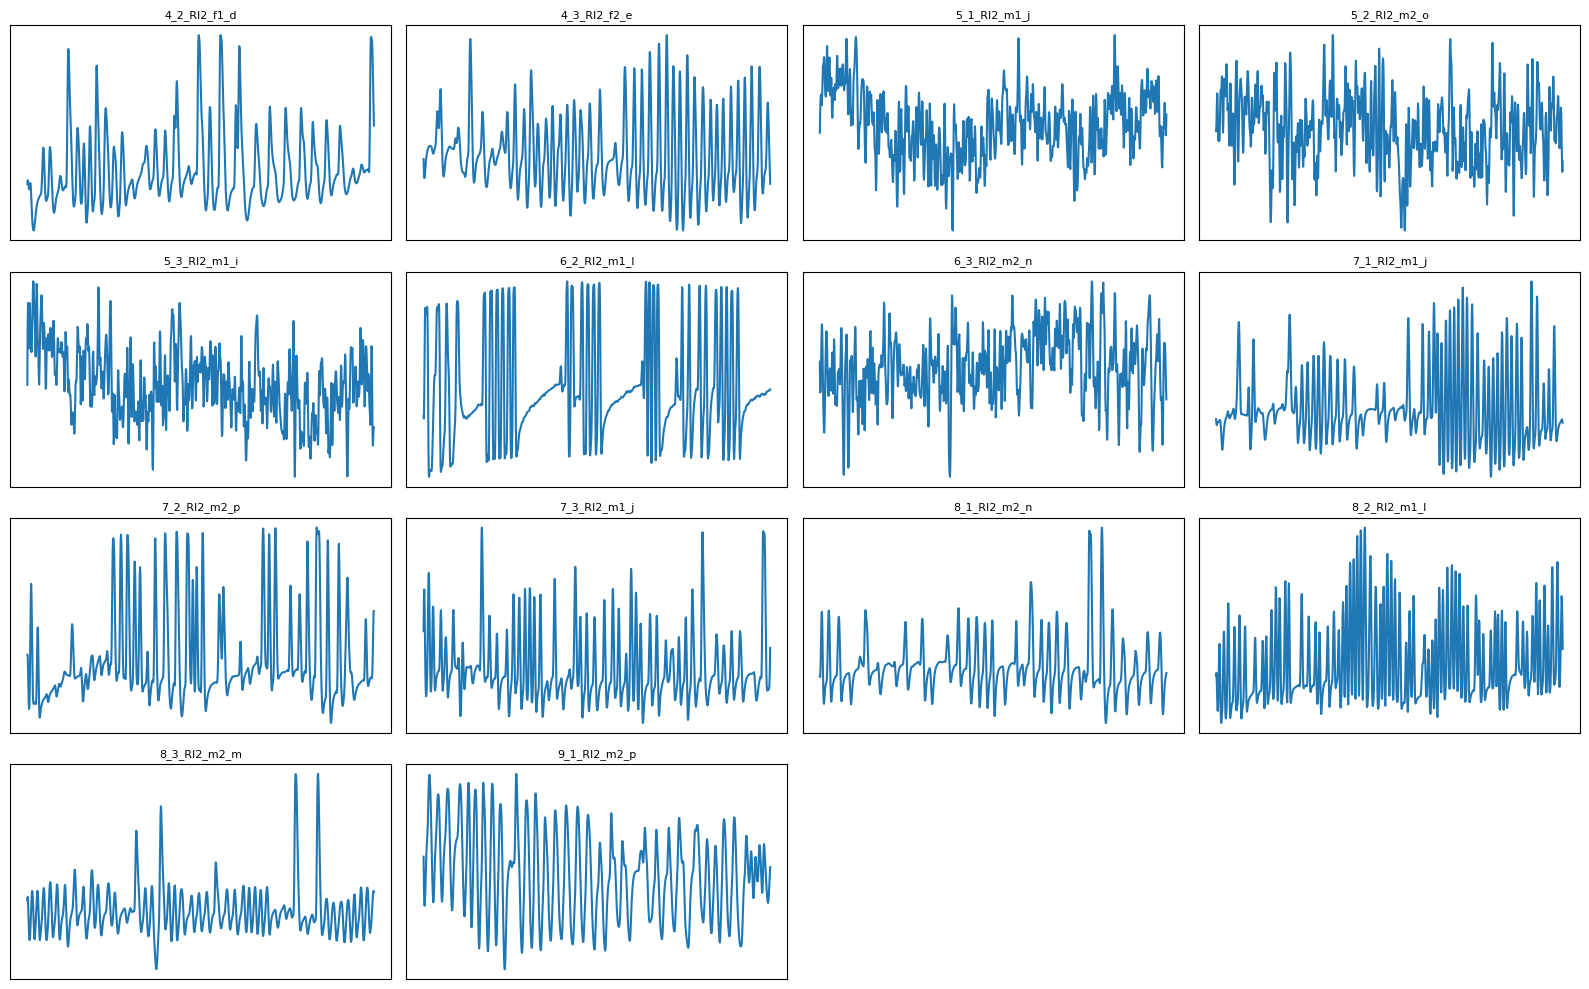

In [ ]:
# Combine both days
all_files = []
for folder in H5_DIRS.values():
    for fname in os.listdir(folder):
        if fname.endswith(".h5"):
            all_files.append(os.path.join(folder, fname))

print("Total files:", len(all_files))

batch_size = 16  # show 16 at a time
samples = 1000   # first ~10 seconds (100 Hz)

for start in range(0, len(all_files), batch_size):
    batch = all_files[start:start+batch_size]
    
    cols = 4
    rows = math.ceil(len(batch) / cols)
    
    plt.figure(figsize=(4*cols, 2.5*rows))
    
    for i, h5_file in enumerate(batch):
        rsp, t = load_resp_simple(h5_file)
        
        plt.subplot(rows, cols, i+1)
        plt.plot(t[:samples], rsp[:samples])
        plt.title(os.path.basename(h5_file)[:12], fontsize=8)
        plt.xticks([])
        plt.yticks([])
    
    plt.tight_layout()
    plt.show()


In [153]:
# Find the exact file
matches = []
for folder in H5_DIRS.values():
    matches.extend(glob.glob(os.path.join(folder, "1_1_RI2*_off_*.h5")))

print("Matches found:")
for m in matches:
    print(os.path.basename(m))

# Pick first match
h5_file = matches[0]

print("\nLoading:", os.path.basename(h5_file))

rsp, t = load_resp_simple(h5_file)



Matches found:
1_1_RI2_f2_h_off_20260119_134817.h5

Loading: 1_1_RI2_f2_h_off_20260119_134817.h5


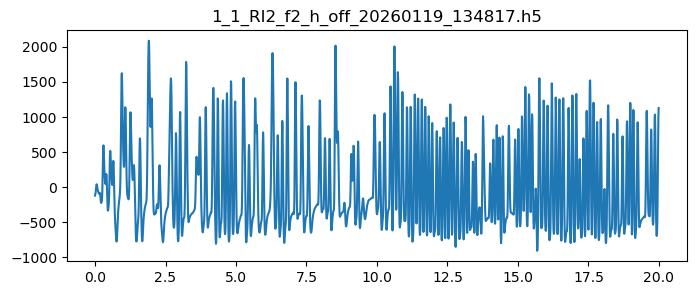

In [154]:
plt.figure(figsize=(8,3))
plt.plot(t[:2000], rsp[:2000])
plt.title(os.path.basename(h5_file))
plt.show()


In [155]:
print("File:", os.path.basename(h5_file))
print("Length:", len(rsp))
print("STD:", np.std(rsp))


File: 1_1_RI2_f2_h_off_20260119_134817.h5
Length: 25604
STD: 797.3788989142688


Total windows: 9

Window 1/9
STD: 617.5008746320063
Range: 3751.2623170543334


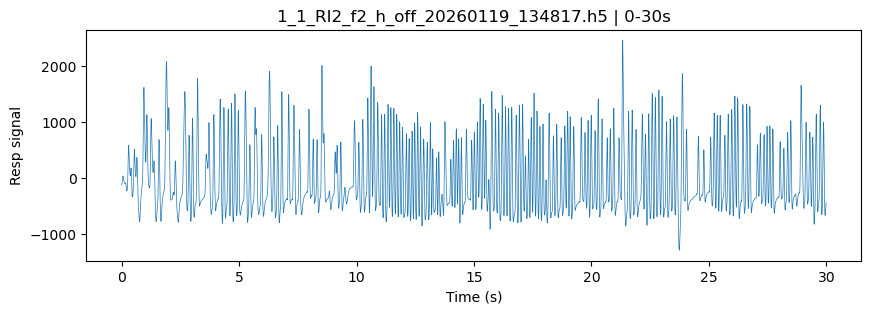


Window 2/9
STD: 753.0537187964312
Range: 5149.6965915680485


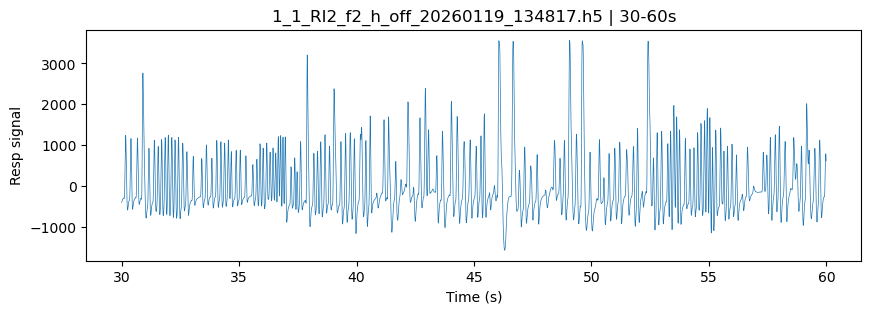


Window 3/9
STD: 932.0070041489475
Range: 5478.549913476957


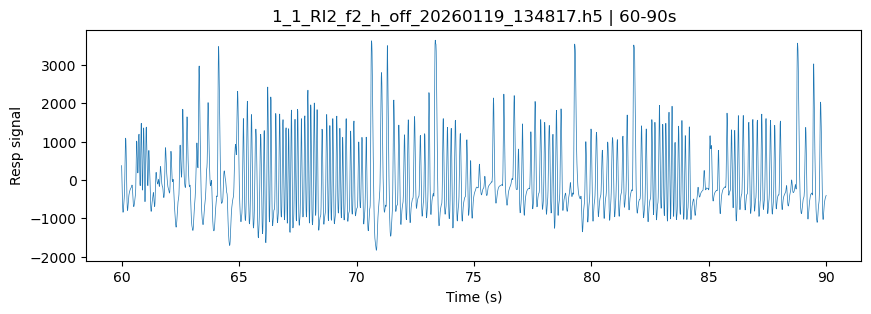


Window 4/9
STD: 801.8113271026358
Range: 5009.560941024926


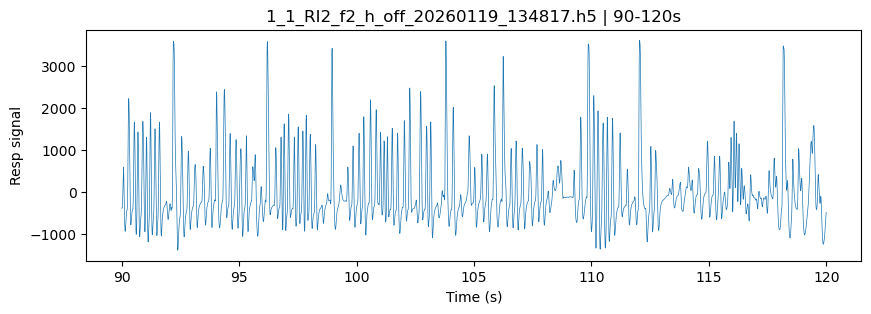


Window 5/9
STD: 903.7743934058759
Range: 5191.228969476196


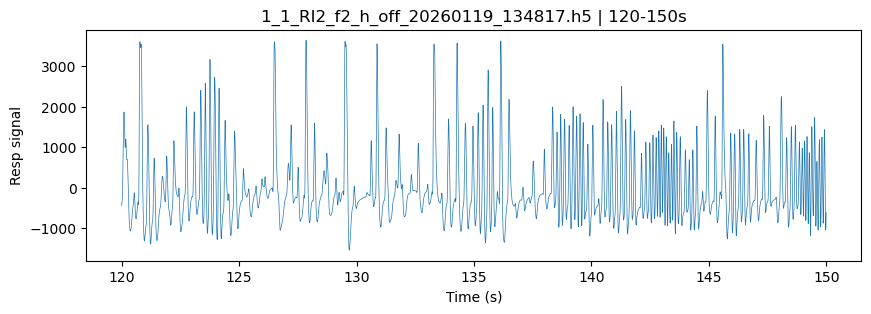


Window 6/9
STD: 862.7768694319527
Range: 5360.66074670511


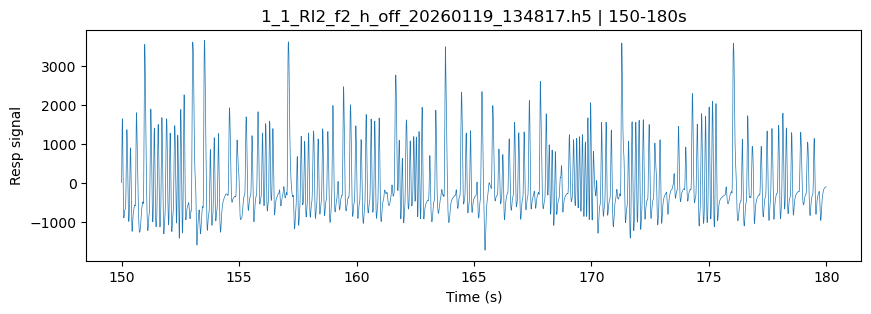


Window 7/9
STD: 772.1864007204266
Range: 5406.982851216313


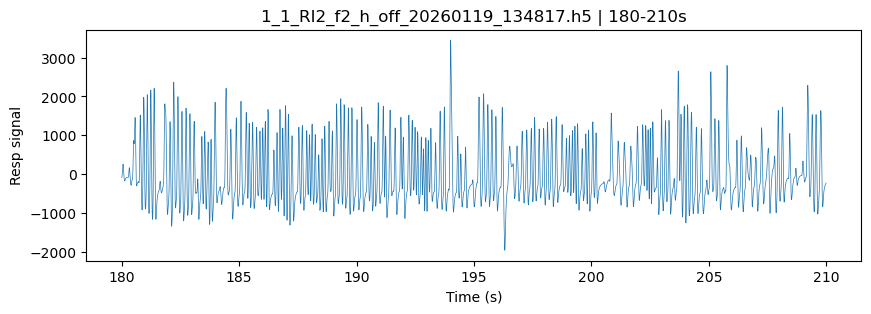


Window 8/9
STD: 759.0661033015507
Range: 5462.921263227845


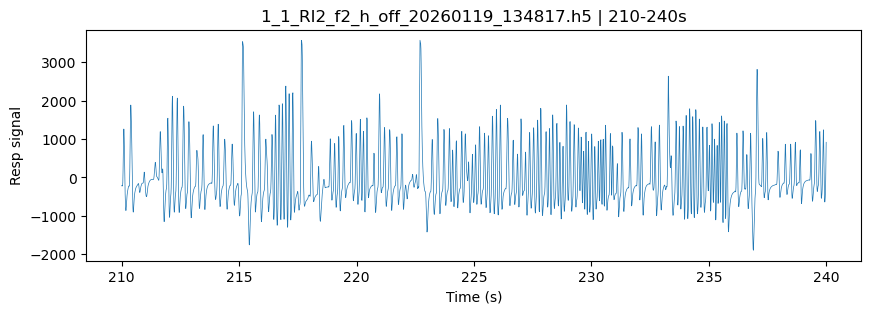


Window 9/9
STD: 659.7069278370138
Range: 3278.4739756509334


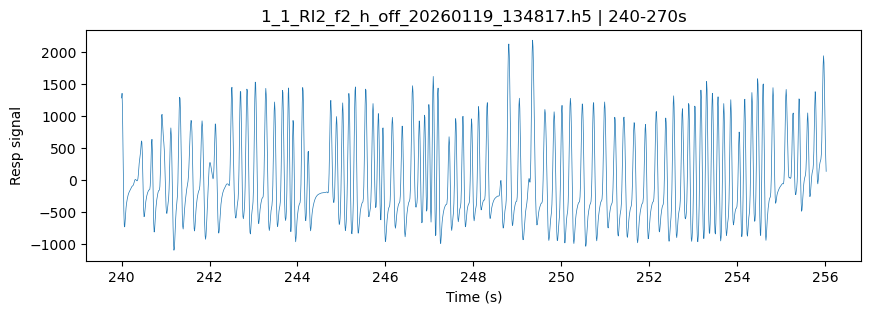

In [156]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- SETTINGS ----------
sampling_rate = 100   # Hz
window_sec = 30       # seconds per chunk
samples_per_window = window_sec * sampling_rate

total_samples = len(rsp)
n_windows = int(np.ceil(total_samples / samples_per_window))

print("Total windows:", n_windows)

# ---------- LOOP THROUGH WINDOWS ----------
for w in range(n_windows):
    
    start = w * samples_per_window
    end = min((w + 1) * samples_per_window, total_samples)

    chunk = rsp[start:end]
    time_chunk = np.arange(start, end) / sampling_rate

    print(f"\nWindow {w+1}/{n_windows}")
    print("STD:", np.std(chunk))
    print("Range:", np.max(chunk) - np.min(chunk))

    plt.figure(figsize=(10, 3))
    plt.plot(time_chunk, chunk, linewidth=0.5)
    plt.title(f"{os.path.basename(h5_file)} | {w*window_sec}-{(w+1)*window_sec}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Resp signal")
    plt.show()


In [157]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ---------- SETTINGS ----------
sampling_rate = 100   # Hz
window_sec = 30       # seconds per chunk
samples_per_window = window_sec * sampling_rate

qc_folder = r"D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2"
os.makedirs(qc_folder, exist_ok=True)

total_samples = len(rsp)
n_windows = int(np.ceil(total_samples / samples_per_window))

print("Total windows:", n_windows)

base_name = os.path.basename(h5_file).replace(".h5", "")

# ---------- LOOP THROUGH WINDOWS ----------
for w in range(n_windows):
    
    start = w * samples_per_window
    end = min((w + 1) * samples_per_window, total_samples)

    chunk = rsp[start:end]
    time_chunk = np.arange(start, end) / sampling_rate

    print(f"\nWindow {w+1}/{n_windows}")
    print("STD:", np.std(chunk))
    print("Range:", np.max(chunk) - np.min(chunk))

    fig = plt.figure(figsize=(10, 3))
    plt.plot(time_chunk, chunk, linewidth=0.5)
    plt.title(f"{base_name} | {w*window_sec}-{(w+1)*window_sec}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Resp signal")

    save_path = os.path.join(
        qc_folder,
        f"{base_name}_window_{w+1}.png"
    )

    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print("Saved:", save_path)


Total windows: 9

Window 1/9
STD: 617.5008746320063
Range: 3751.2623170543334
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\1_1_RI2_f2_h_off_20260119_134817_window_1.png

Window 2/9
STD: 753.0537187964312
Range: 5149.6965915680485
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\1_1_RI2_f2_h_off_20260119_134817_window_2.png

Window 3/9
STD: 932.0070041489475
Range: 5478.549913476957
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\1_1_RI2_f2_h_off_20260119_134817_window_3.png

Window 4/9
STD: 801.8113271026358
Range: 5009.560941024926
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\1_1_RI2_f2_h_off_20260119_134817_window_4.png

Window 5/9
STD: 903.7743934058759
Range: 5191.228969476196
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\1_1_RI2_f2_h_off_20260119_134817_window_5.png

Window 6/9
STD: 862.7768694319527
Range: 5360.66074670511
Saved: D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2\1_1_RI2_f2_h_off_20260119_134817_window_6.png

Window 7/9
STD: 772.1864007204266
Range: 5406.98285121631

In [158]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# SETTINGS
# ----------------------------
sampling_rate = 100  # Hz
window_sec = 30
samples_per_window = window_sec * sampling_rate

qc_folder = r"D:\BLA_ChR_resp\QC_fulltrace_plots_RI1_2"
os.makedirs(qc_folder, exist_ok=True)

# ----------------------------
# LOOP THROUGH ALL FILES
# ----------------------------
for day, folder in H5_DIRS.items():

    h5_files = glob.glob(os.path.join(folder, "*.h5"))

    for h5_file in h5_files:

        base_name = os.path.basename(h5_file).replace(".h5", "")
        print("\n====================================")
        print("Processing:", base_name)
        print("====================================")

        try:
            rsp, t = load_resp_simple(h5_file)
        except Exception as e:
            print("Failed to load:", e)
            continue

        total_samples = len(rsp)
        n_windows = int(np.ceil(total_samples / samples_per_window))

        print("Total windows:", n_windows)
        print("Full STD:", np.std(rsp))
        print("Full Range:", np.max(rsp) - np.min(rsp))

        for w in range(n_windows):

            start = w * samples_per_window
            end = min((w + 1) * samples_per_window, total_samples)

            chunk = rsp[start:end]
            time_chunk = np.arange(start, end) / sampling_rate

            chunk_std = np.std(chunk)
            chunk_range = np.max(chunk) - np.min(chunk)

            print(f"Window {w+1}/{n_windows} | STD: {chunk_std:.2f} | Range: {chunk_range:.2f}")

            fig = plt.figure(figsize=(10, 3))
            plt.plot(time_chunk, chunk, linewidth=0.5)
            plt.title(f"{base_name} | {w*window_sec}-{(w+1)*window_sec}s")
            plt.xlabel("Time (s)")
            plt.ylabel("Resp signal")

            save_path = os.path.join(
                qc_folder,
                f"{base_name}_window_{w+1}.png"
            )

            fig.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.close(fig)

        print("Finished:", base_name)



Processing: 1_1_RI1_f1_d_on_20260111_164638
Total windows: 9
Full STD: 398.2905686420882
Full Range: 4448.892152458331
Window 1/9 | STD: 419.08 | Range: 3475.49
Window 2/9 | STD: 446.70 | Range: 2577.21
Window 3/9 | STD: 435.29 | Range: 2610.07
Window 4/9 | STD: 401.30 | Range: 3969.82
Window 5/9 | STD: 355.11 | Range: 2561.65
Window 6/9 | STD: 339.23 | Range: 2126.05
Window 7/9 | STD: 379.85 | Range: 2642.79
Window 8/9 | STD: 358.94 | Range: 3278.65
Window 9/9 | STD: 554.54 | Range: 2951.98
Finished: 1_1_RI1_f1_d_on_20260111_164638

Processing: 1_2_RI1_f2_f_off_20260109_165330
Total windows: 18
Full STD: 326.21028212017535
Full Range: 2716.663758070243
Window 1/18 | STD: 212.28 | Range: 1129.10
Window 2/18 | STD: 217.20 | Range: 1334.07
Window 3/18 | STD: 317.21 | Range: 2532.13
Window 4/18 | STD: 336.57 | Range: 1770.36
Window 5/18 | STD: 316.14 | Range: 2165.73
Window 6/18 | STD: 322.66 | Range: 1735.18
Window 7/18 | STD: 328.55 | Range: 1913.33
Window 8/18 | STD: 315.47 | Range: 2

In [65]:
import numpy as np
import pandas as pd

qc_metrics = []

for h5_file in all_files:
    rsp, t = load_resp_simple(h5_file)
    
    qc_metrics.append({
        "file": os.path.basename(h5_file),
        "std": np.std(rsp),
        "range": np.max(rsp) - np.min(rsp),
        "mean": np.mean(rsp)
    })

qc_df = pd.DataFrame(qc_metrics)

qc_df.sort_values("std")


,file,std,range,mean
84,5_3_RI2_m1_i_off_20260120_155725.h5,0.894183,6.898531,0.009233
83,5_2_RI2_m2_o_off_20260120_134320.h5,0.960066,17.405362,0.003098
86,6_3_RI2_m2_n_off_20260120_114131.h5,1.005168,8.668542,-0.005694
33,4_1_RI1_f1_b_off_20260110_165525.h5,1.110086,9.453438,0.013350
13,5_2_RI1_m2_n_off_20260110_135659.h5,1.207971,10.065365,-0.009803
...,...,...,...,...
52,2_2_RI2_f2_3_on_20260119_144717.h5,936.462965,11037.536078,2.005107
50,1_3_RI2_f2_f_on_20260119_152733.h5,948.559310,8820.529149,-7.250202
67,8_1_RI2_m1_i_off_20260119_162623.h5,1156.394629,7793.736938,-0.209849
70,9_1_RI2_m1_k_off_20260119_153823.h5,1465.629008,12512.426125,-0.808474


In [65]:
qc_df

,file,std,range,mean
0,1_1_RI1_f1_d_on_20260111_164638.h5,398.290569,4448.892152,-0.529422
1,1_2_RI1_f2_f_off_20260109_165330.h5,326.210282,2716.663758,0.307675
2,1_3_RI1_f1_c_off_20260110_130254.h5,277.362850,2673.364308,1.232536
3,2_1_RI1_f2_h_on_20260110_145355.h5,250.412452,2576.901473,1.841883
4,2_2_RI1_f1_b_off_20260109_150435.h5,428.592140,3936.356729,-0.198125
...,...,...,...,...
89,7_3_RI2_m1_j_on_20260120_153051.h5,226.368960,2031.508427,0.397607
90,8_1_RI2_m2_n_on_20260120_132851.h5,266.844618,2359.509083,-0.007007
91,8_2_RI2_m1_l_off_20260120_171457.h5,180.031946,1759.802420,-0.439332
92,8_3_RI2_m2_m_on_20260120_162340.h5,793.858246,7719.137656,-0.886145


Files with STD < 20:
5      2_3_RI1_f2_f_on_20260110_132734.h5
12     5_1_RI1_m1_j_on_20260111_150428.h5
13    5_2_RI1_m2_n_off_20260110_135659.h5
14    5_3_RI1_m1_k_off_20260109_183135.h5
15    6_2_RI1_m1_j_off_20260109_191750.h5
16    6_3_RI1_m2_m_off_20260109_174951.h5
20     8_1_RI1_m2_m_on_20260110_144121.h5
29    2_3_RI1_f1_a_off_20260111_141011.h5
33    4_1_RI1_f1_b_off_20260110_165525.h5
36    5_1_RI1_m2_m_off_20260110_174649.h5
37     5_2_RI1_m1_j_on_20260111_133010.h5
38     5_3_RI1_m2_o_on_20260110_160743.h5
39     6_2_RI2_m2_n_on_20260110_190944.h5
40     6_3_RI1_m1_i_on_20260110_181825.h5
44    8_1_RI1_m1_j_off_20260111_135412.h5
53    2_3_RI2_f1_d_off_20260119_160619.h5
60     5_2_RI2_m1_k_on_20260119_175411.h5
61     5_3_RI2_m2_m_on_20260119_161502.h5
63     6_3_RI2_m1_k_on_20260119_165027.h5
76     2_3_RI2_f2_h_on_20260120_144851.h5
82     5_1_RI2_m1_j_on_20260120_172322.h5
83    5_2_RI2_m2_o_off_20260120_134320.h5
84    5_3_RI2_m1_i_off_20260120_155725.h5
86    6_3_RI2

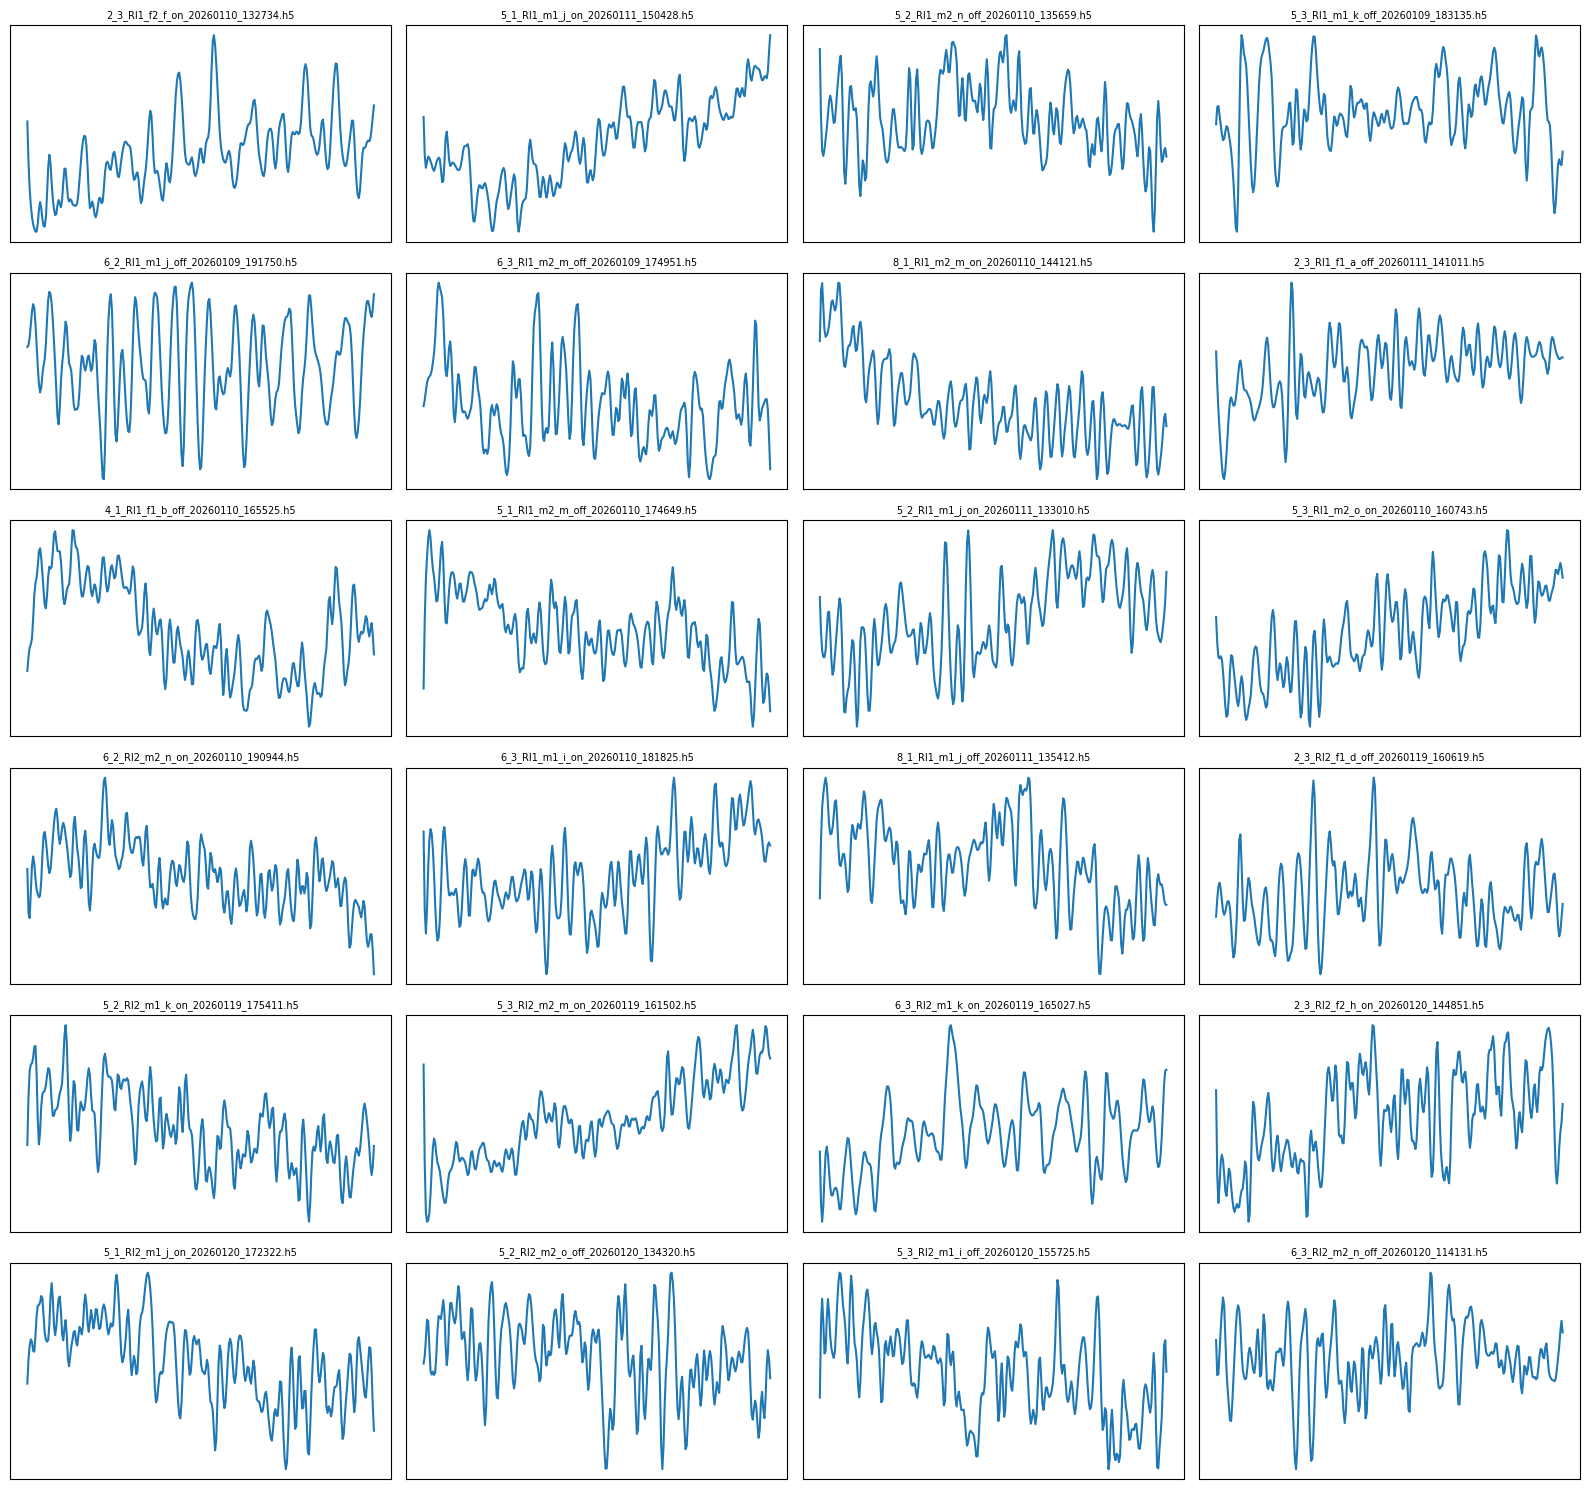

In [159]:
low_std_files = qc_df[qc_df["std"] < 20]["file"]

print("Files with STD < 20:")
print(low_std_files)

import math
import matplotlib.pyplot as plt

low_paths = [f for f in all_files if os.path.basename(f) in low_std_files.values]

cols = 4
rows = math.ceil(len(low_paths) / cols)

plt.figure(figsize=(4*cols, 2.5*rows))

for i, h5_file in enumerate(low_paths):
    rsp, t = load_resp_simple(h5_file)
    plt.subplot(rows, cols, i+1)
    plt.plot(t[:300], rsp[:300])
    plt.title(os.path.basename(h5_file), fontsize=7)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


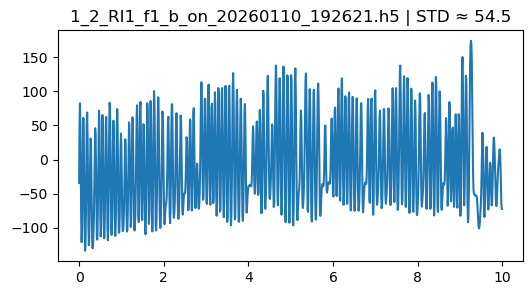

In [68]:
mid_std_file = qc_df[(qc_df["std"] > 40) & (qc_df["std"] < 80)]["file"].iloc[0]

mid_path = [f for f in all_files if os.path.basename(f) == mid_std_file][0]

rsp_mid, t_mid = load_resp_simple(mid_path)

plt.figure(figsize=(6,3))
plt.plot(t_mid[:1000], rsp_mid[:1000])
plt.title(f"{mid_std_file} | STD ≈ {qc_df[qc_df['file']==mid_std_file]['std'].values[0]:.1f}")
plt.show()


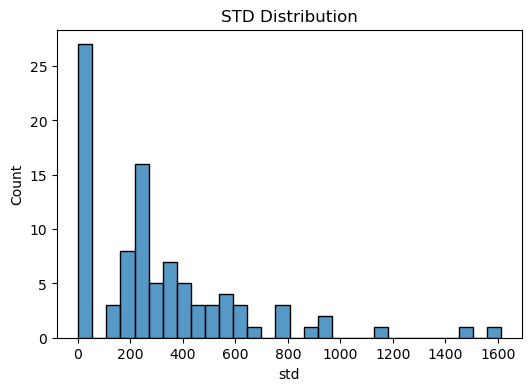

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(qc_df["std"], bins=30)
plt.title("STD Distribution")
plt.show()


In [85]:
cage5_files = [f for f in all_files if os.path.basename(f).startswith("5_")]
non_cage5_files = [f for f in all_files if not os.path.basename(f).startswith("5_")]

print("Cage 5 files:", len(cage5_files))
print("Non-cage 5 files:", len(non_cage5_files))


Cage 5 files: 12
Non-cage 5 files: 82


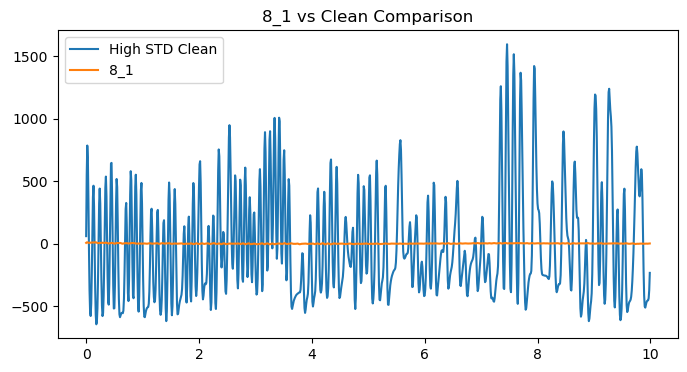

In [86]:
file_8_1 = [f for f in all_files if "8_1" in f][0]
clean_example = non_cage5_files[0]

rsp_8, t_8 = load_resp_simple(file_8_1)
rsp_clean, t_clean = load_resp_simple(clean_example)

plt.figure(figsize=(8,4))
plt.plot(t_clean[:1000], rsp_clean[:1000], label="High STD Clean")
plt.plot(t_8[:1000], rsp_8[:1000], label="8_1")
plt.legend()
plt.title("8_1 vs Clean Comparison")
plt.show()

In [87]:
import pandas as pd
import numpy as np

qc_metrics = []

for h5_file in all_files:
    rsp, t = load_resp_simple(h5_file)
    
    qc_metrics.append({
        "file": os.path.basename(h5_file),
        "cage5": os.path.basename(h5_file).startswith("5_"),
        "std": np.std(rsp)
    })

qc_df = pd.DataFrame(qc_metrics)

print("Mean STD (cage5):", qc_df[qc_df["cage5"]]["std"].mean())
print("Mean STD (non-cage5):", qc_df[~qc_df["cage5"]]["std"].mean())


Mean STD (cage5): 6.959855273487868
Mean STD (non-cage5): 352.253031257783


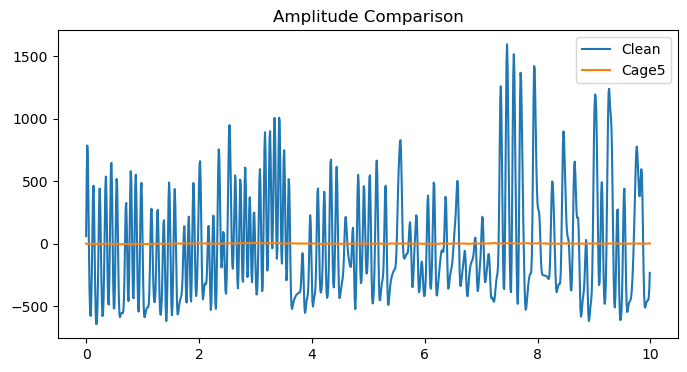

In [74]:
clean_example = non_cage5_files[0]
cage5_example = cage5_files[0]

rsp_clean, t_clean = load_resp_simple(clean_example)
rsp_c5, t_c5 = load_resp_simple(cage5_example)

plt.figure(figsize=(8,4))
plt.plot(t_clean[:1000], rsp_clean[:1000], label="Clean")
plt.plot(t_c5[:1000], rsp_c5[:1000], label="Cage5")
plt.legend()
plt.title("Amplitude Comparison")
plt.show()


In [79]:
qc_df.head()


,file,cage5,std
0,1_1_RI1_f1_d_on_20260111_164638.h5,False,398.290569
1,1_2_RI1_f2_f_off_20260109_165330.h5,False,326.210282
2,1_3_RI1_f1_c_off_20260110_130254.h5,False,277.362850
3,2_1_RI1_f2_h_on_20260110_145355.h5,False,250.412452
4,2_2_RI1_f1_b_off_20260109_150435.h5,False,428.592140


In [121]:
# Identify bad files
bad_files = qc_df[qc_df["std"] < 20]["file"]

# Extract subject IDs
bad_subjects = set(["_".join(f.split("_")[:2]) for f in bad_files])

print("Subjects flagged for exclusion:")
print(bad_subjects)
print("Total subjects removed:", len(bad_subjects))

# Filter respiration dataframe
df_resp_clean = df_clean[~df_clean["Subject"].isin(bad_subjects)].copy()

print("Remaining respiration subjects:", df_resp_clean["Subject"].nunique())


Subjects flagged for exclusion:
{'8_1', '5_2', '2_3', '6_2', '5_3', '4_1', '6_3', '5_1'}
Total subjects removed: 8
Remaining respiration subjects: 16


In [138]:
def extract_sex(subject):
    cage = int(subject.split("_")[0])
    return "Female" if cage <= 4 else "Male"

def extract_virus(subject):
    mouse = int(subject.split("_")[1])
    return "ChR" if mouse % 2 == 1 else "GFP"

df_resp_clean["Sex"] = df_resp_clean["Subject"].apply(extract_sex)
df_resp_clean["Virus"] = df_resp_clean["Subject"].apply(extract_virus)


In [139]:
df_resp_clean.groupby(["Sex", "Virus"])["Subject"].nunique()


Sex     Virus
Female  ChR      6
        GFP      4
Male    ChR      4
        GFP      2
Name: Subject, dtype: int64

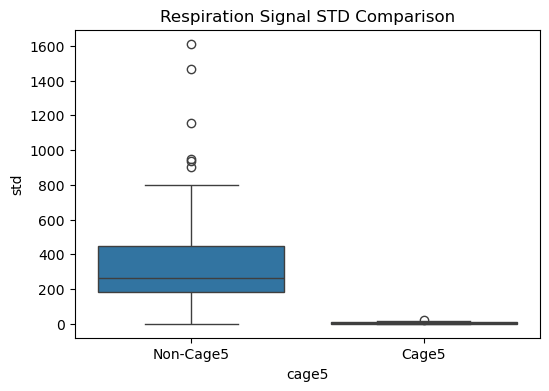

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="cage5", y="std", data=qc_df)
plt.xticks([0,1], ["Non-Cage5", "Cage5"])
plt.title("Respiration Signal STD Comparison")
plt.show()


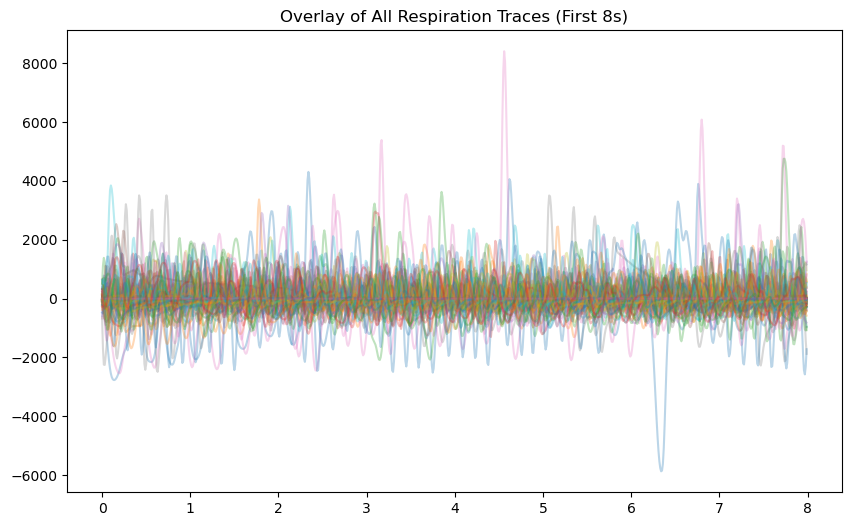

In [131]:
plt.figure(figsize=(10,6))

for h5_file in all_files:
    rsp, t = load_resp_simple(h5_file)
    plt.plot(t[:800], rsp[:800], alpha=0.3)

plt.title("Overlay of All Respiration Traces (First 8s)")
plt.show()


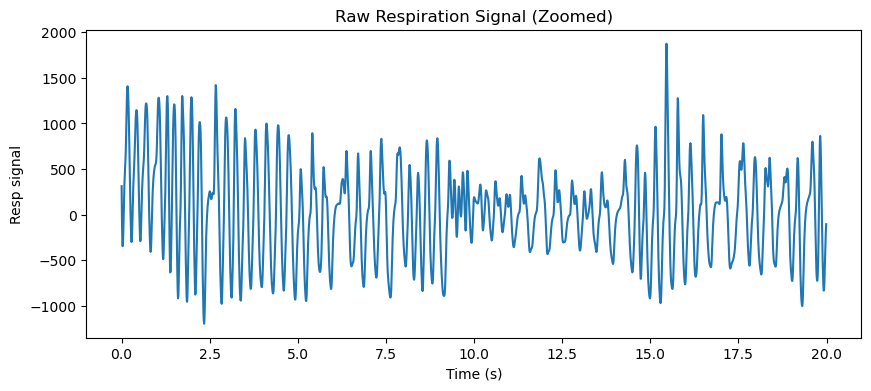

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(t[:2000], rsp[:2000])  # first ~20 seconds if sampling_rate=100
plt.xlabel("Time (s)")
plt.ylabel("Resp signal")
plt.title("Raw Respiration Signal (Zoomed)")
plt.show()


In [67]:
rows = []

for day, h5_dir in H5_DIRS.items():
    h5_files = glob.glob(os.path.join(h5_dir, "*.h5"))

    for h5_file in h5_files:
        rsp, t = load_resp_simple(h5_file)

        social_rate = get_sniff_respiratory_rate(
            signal=rsp,
            time=t,
            sniff_start=60,
            sniff_end=240,
            sampling_rate=100
        )

        rows.append({
            "File": os.path.basename(h5_file),
            "SocialRespRate": social_rate,
        })

df = pd.DataFrame(rows)


In [81]:
df["Laser"] = df["File"].str.contains("_on_").map(
    {True: "ON", False: "OFF"}
)

# Extract cage number (first number before "_")
df["Cage"] = df["File"].str.extract(r"^(\d+)").astype(int)

# Assign virus by cage parity
df["Virus"] = df["Cage"].apply(
    lambda x: "ChR" if x % 2 == 1 else "GFP"
)


df["Subject"] = df["File"].str.extract(r"(\d_\d)")
# Extract condition (RI1 vs RI2)
df["Condition"] = df["File"].apply(lambda x: x.split("_")[2])
df.head()


,File,SocialRespRate,Laser,Cage,Virus,Subject,Condition
0,1_1_RI1_f1_d_on_20260111_164638.h5,9.152318,ON,1,ChR,1_1,RI1
1,1_2_RI1_f2_f_off_20260109_165330.h5,10.288113,OFF,1,ChR,1_2,RI1
2,1_3_RI1_f1_c_off_20260110_130254.h5,8.591796,OFF,1,ChR,1_3,RI1
3,2_1_RI1_f2_h_on_20260110_145355.h5,9.249470,ON,2,GFP,2_1,RI1
4,2_2_RI1_f1_b_off_20260109_150435.h5,8.654789,OFF,2,GFP,2_2,RI1



Condition: Pre
Subjects: 17

--- GFP ---
2_1 | OFF: 9.11 | ON: 9.25
2_2 | OFF: 8.65 | ON: 8.75
4_1 | OFF: 8.79 | ON: 6.60
4_2 | OFF: 8.64 | ON: 7.93
4_3 | OFF: 8.44 | ON: 7.96
8_2 | OFF: 9.33 | ON: 9.14
8_3 | OFF: 9.32 | ON: 9.65

--- ChR ---
1_1 | OFF: 8.93 | ON: 9.15
1_2 | OFF: 10.29 | ON: 8.96
1_3 | OFF: 8.59 | ON: 9.48
3_1 | OFF: 8.70 | ON: 9.10
3_2 | OFF: 8.13 | ON: 8.52
3_3 | OFF: 7.64 | ON: 7.91
7_1 | OFF: 8.57 | ON: 8.72
7_2 | OFF: 9.20 | ON: 8.13
7_3 | OFF: 8.01 | ON: 8.65
9_1 | OFF: 9.16 | ON: 9.52

Condition: Post
Subjects: 16

--- GFP ---
2_1 | OFF: 4.67 | ON: 5.21
2_2 | OFF: 4.84 | ON: 5.16
4_2 | OFF: 5.09 | ON: 5.53
4_3 | OFF: 5.93 | ON: 5.36
8_2 | OFF: 7.55 | ON: 7.70
8_3 | OFF: 6.46 | ON: 4.90

--- ChR ---
1_1 | OFF: 6.31 | ON: 6.19
1_2 | OFF: 2.92 | ON: 6.91
1_3 | OFF: 4.92 | ON: 5.43
3_1 | OFF: 6.07 | ON: 6.26
3_2 | OFF: 5.34 | ON: 6.61
3_3 | OFF: 5.90 | ON: 7.02
7_1 | OFF: 6.68 | ON: 6.98
7_2 | OFF: 6.71 | ON: 5.74
7_3 | OFF: 5.43 | ON: 7.05
9_1 | OFF: 4.73 | ON: 5.

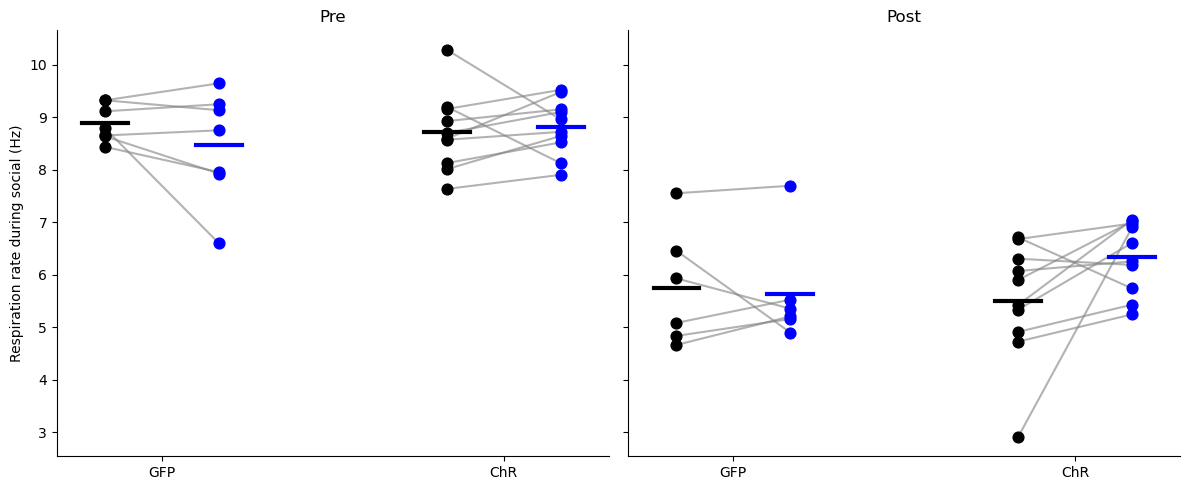

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# 1️⃣ Apply Exclusions
# -----------------------------------

df_clean = df[~df["Subject"].isin(exclude_subjects)].copy()

condition_labels = {
    "RI1": "Pre",
    "RI2": "Post"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, condition in zip(axes, ["RI1", "RI2"]):

    df_cond = df_clean[df_clean["Condition"] == condition].copy()

    # Keep only properly paired subjects
    counts = df_cond.groupby("Subject")["Laser"].nunique()
    good_subjects = counts[counts == 2].index
    df_cond = df_cond[df_cond["Subject"].isin(good_subjects)]

    print("\n==============================")
    print("Condition:", condition_labels[condition])
    print("Subjects:", len(good_subjects))
    print("==============================")

    xpos = {
        ("GFP", "OFF"): 0,
        ("GFP", "ON"):  1,
        ("ChR", "OFF"): 3,
        ("ChR", "ON"):  4,
    }

    for virus in ["GFP", "ChR"]:

        df_v = df_cond[df_cond["Virus"] == virus]

        print(f"\n--- {virus} ---")

        for subject in df_v["Subject"].unique():

            sub_df = df_v[df_v["Subject"] == subject]

            off_val = sub_df[sub_df["Laser"] == "OFF"]["SocialRespRate"].values[0]
            on_val  = sub_df[sub_df["Laser"] == "ON"]["SocialRespRate"].values[0]

            print(f"{subject} | OFF: {off_val:.2f} | ON: {on_val:.2f}")

            x = [xpos[(virus, "OFF")], xpos[(virus, "ON")]]
            y = [off_val, on_val]

            # Paired connection
            ax.plot(x, y, color="gray", alpha=0.6, zorder=1)

            # OFF = black
            ax.scatter(
                xpos[(virus, "OFF")],
                off_val,
                color="black",
                s=60,
                zorder=2
            )

            # ON = blue
            ax.scatter(
                xpos[(virus, "ON")],
                on_val,
                color="blue",
                s=60,
                zorder=2
            )

        # -------------------------
        # Mean Bars
        # -------------------------

        for laser in ["OFF", "ON"]:

            vals = df_v[df_v["Laser"] == laser]["SocialRespRate"]

            if len(vals) > 0:
                x = xpos[(virus, laser)]
                color = "blue" if laser == "ON" else "black"

                ax.plot(
                    [x - 0.2, x + 0.2],
                    [vals.mean(), vals.mean()],
                    color=color,
                    lw=3,
                    zorder=3
                )

    # Formatting
    ax.set_xticks([0.5, 3.5])
    ax.set_xticklabels(["GFP", "ChR"])
    ax.set_title(condition_labels[condition])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Respiration rate during social (Hz)")

plt.tight_layout()
plt.show()



Female | Pre
Subjects: 11
2_1 | OFF: 9.11 | ON: 9.25
2_2 | OFF: 8.65 | ON: 8.75
4_1 | OFF: 8.79 | ON: 6.60
4_2 | OFF: 8.64 | ON: 7.93
4_3 | OFF: 8.44 | ON: 7.96
1_1 | OFF: 8.93 | ON: 9.15
1_2 | OFF: 10.29 | ON: 8.96
1_3 | OFF: 8.59 | ON: 9.48
3_1 | OFF: 8.70 | ON: 9.10
3_2 | OFF: 8.13 | ON: 8.52
3_3 | OFF: 7.64 | ON: 7.91

Female | Post
Subjects: 10
2_1 | OFF: 4.67 | ON: 5.21
2_2 | OFF: 4.84 | ON: 5.16
4_2 | OFF: 5.09 | ON: 5.53
4_3 | OFF: 5.93 | ON: 5.36
1_1 | OFF: 6.31 | ON: 6.19
1_2 | OFF: 2.92 | ON: 6.91
1_3 | OFF: 4.92 | ON: 5.43
3_1 | OFF: 6.07 | ON: 6.26
3_2 | OFF: 5.34 | ON: 6.61
3_3 | OFF: 5.90 | ON: 7.02

Male | Pre
Subjects: 6
8_2 | OFF: 9.33 | ON: 9.14
8_3 | OFF: 9.32 | ON: 9.65
7_1 | OFF: 8.57 | ON: 8.72
7_2 | OFF: 9.20 | ON: 8.13
7_3 | OFF: 8.01 | ON: 8.65
9_1 | OFF: 9.16 | ON: 9.52

Male | Post
Subjects: 6
8_2 | OFF: 7.55 | ON: 7.70
8_3 | OFF: 6.46 | ON: 4.90
7_1 | OFF: 6.68 | ON: 6.98
7_2 | OFF: 6.71 | ON: 5.74
7_3 | OFF: 5.43 | ON: 7.05
9_1 | OFF: 4.73 | ON: 5.25


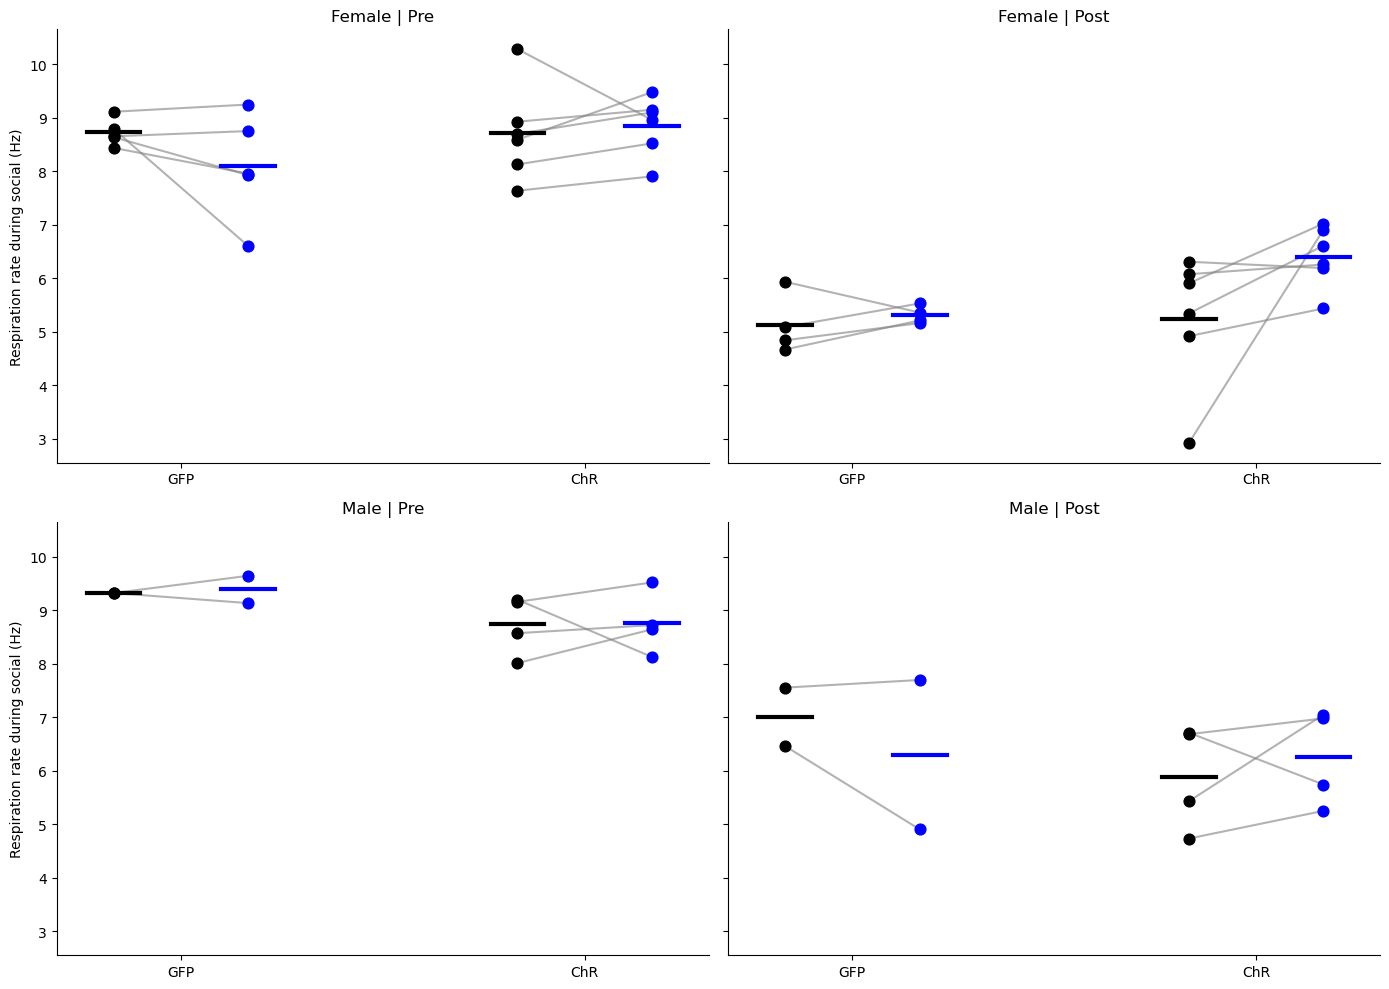

In [98]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# 1️⃣ Apply Exclusions
# -----------------------------------

df_clean = df[~df["Subject"].isin(exclude_subjects)].copy()

# -----------------------------------
# 2️⃣ Add Sex from Cage
# -----------------------------------

df_clean["Cage"] = df_clean["Subject"].str.split("_").str[0].astype(int)

df_clean["Sex"] = np.where(
    df_clean["Cage"].isin([1,2,3,4]),
    "Female",
    "Male"
)

condition_labels = {
    "RI1": "Pre",
    "RI2": "Post"
}

sexes = ["Female", "Male"]
conditions = ["RI1", "RI2"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for row, sex in enumerate(sexes):
    for col, condition in enumerate(conditions):

        ax = axes[row, col]

        df_subset = df_clean[
            (df_clean["Sex"] == sex) &
            (df_clean["Condition"] == condition)
        ].copy()

        # Keep only properly paired subjects
        counts = df_subset.groupby("Subject")["Laser"].nunique()
        good_subjects = counts[counts == 2].index
        df_subset = df_subset[df_subset["Subject"].isin(good_subjects)]

        print("\n==============================")
        print(f"{sex} | {condition_labels[condition]}")
        print("Subjects:", len(good_subjects))
        print("==============================")

        xpos = {
            ("GFP", "OFF"): 0,
            ("GFP", "ON"):  1,
            ("ChR", "OFF"): 3,
            ("ChR", "ON"):  4,
        }

        for virus in ["GFP", "ChR"]:

            df_v = df_subset[df_subset["Virus"] == virus]

            for subject in df_v["Subject"].unique():

                sub_df = df_v[df_v["Subject"] == subject]

                off_val = sub_df[sub_df["Laser"] == "OFF"]["SocialRespRate"].values[0]
                on_val  = sub_df[sub_df["Laser"] == "ON"]["SocialRespRate"].values[0]

                print(f"{subject} | OFF: {off_val:.2f} | ON: {on_val:.2f}")

                x = [xpos[(virus, "OFF")], xpos[(virus, "ON")]]
                y = [off_val, on_val]

                # Paired connection
                ax.plot(x, y, color="gray", alpha=0.6, zorder=1)

                # OFF point (black)
                ax.scatter(
                    xpos[(virus, "OFF")],
                    off_val,
                    color="black",
                    s=60,
                    zorder=2
                )

                # ON point (blue)
                ax.scatter(
                    xpos[(virus, "ON")],
                    on_val,
                    color="blue",
                    s=60,
                    zorder=2
                )

            # Mean bars
            for laser in ["OFF", "ON"]:

                vals = df_v[df_v["Laser"] == laser]["SocialRespRate"]

                if len(vals) > 0:
                    x = xpos[(virus, laser)]
                    color = "blue" if laser == "ON" else "black"

                    ax.plot(
                        [x - 0.2, x + 0.2],
                        [vals.mean(), vals.mean()],
                        color=color,
                        lw=3,
                        zorder=3
                    )

        # Formatting
        ax.set_xticks([0.5, 3.5])
        ax.set_xticklabels(["GFP", "ChR"])
        ax.set_title(f"{sex} | {condition_labels[condition]}")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

axes[0,0].set_ylabel("Respiration rate during social (Hz)")
axes[1,0].set_ylabel("Respiration rate during social (Hz)")

plt.tight_layout()
plt.show()


In [110]:
# =====================================================
# BASIC OVERVIEW
# =====================================================

print("Shape of dataframe:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst 10 rows:")
display(df.head(10))

# =====================================================
# SUBJECT SUMMARY
# =====================================================

print("\nUnique Subjects:")
print(sorted(df["Subject"].unique()))

print("\nNumber of subjects:", df["Subject"].nunique())

# =====================================================
# CHECK VIRUS GROUPS
# =====================================================

print("\nVirus counts:")
print(df["Virus"].value_counts())

# =====================================================
# CHECK LASER CONDITIONS
# =====================================================

print("\nLaser counts:")
print(df["Laser"].value_counts())

print("\nLaser per subject (should be 2 for paired design):")
print(df.groupby("Subject")["Laser"].nunique())

# =====================================================
# LOOK AT RESPIRATION VALUES
# =====================================================

print("\nRespiration summary stats:")
display(
    df.groupby(["Virus", "Laser"])["SocialRespRate"]
      .describe()
)

# =====================================================
# CHECK FOR DUPLICATES
# =====================================================

print("\nDuplicate rows (Virus, Subject, Laser):")
print(df.duplicated(subset=["Virus", "Subject", "Laser"]).sum())

# =====================================================
# CHECK ON vs OFF DIFFERENCE PER SUBJECT
# =====================================================

pivot = (
    df.pivot_table(
        index=["Virus", "Subject"],
        columns="Laser",
        values="SocialRespRate"
    )
)

pivot["ON_minus_OFF"] = pivot["ON"] - pivot["OFF"]

print("\nON - OFF differences per subject:")
display(pivot)


Shape of dataframe: (94, 8)

Columns:
Index(['File', 'SocialRespRate', 'Laser', 'Cage', 'Virus', 'Subject',
       'Condition', 'Sex'],
      dtype='object')

First 10 rows:


,File,SocialRespRate,Laser,Cage,Virus,Subject,Condition,Sex
0,1_1_RI1_f1_d_on_20260111_164638.h5,9.152318,ON,1,ChR,1_1,RI1,Female
1,1_2_RI1_f2_f_off_20260109_165330.h5,10.288113,OFF,1,ChR,1_2,RI1,Female
2,1_3_RI1_f1_c_off_20260110_130254.h5,8.591796,OFF,1,ChR,1_3,RI1,Female
3,2_1_RI1_f2_h_on_20260110_145355.h5,9.249470,ON,2,GFP,2_1,RI1,Female
4,2_2_RI1_f1_b_off_20260109_150435.h5,8.654789,OFF,2,GFP,2_2,RI1,Female
5,2_3_RI1_f2_f_on_20260110_132734.h5,8.291091,ON,2,GFP,2_3,RI1,Female
6,3_1_RI1_f1_b_on_20260111_154618.h5,9.101620,ON,3,ChR,3_1,RI1,Female
7,3_2_RI1_f1_a_off_20260114_161949.h5,8.129087,OFF,3,ChR,3_2,RI1,Female
8,3_3_RI1_f1_c_on_20260111_162426.h5,7.905516,ON,3,ChR,3_3,RI1,Female
9,4_1_RI1_f2_h_on_20260111_161337.h5,6.603175,ON,4,GFP,4_1,RI1,Female



Unique Subjects:
['1_1', '1_2', '1_3', '2_1', '2_2', '2_3', '3_1', '3_2', '3_3', '4_1', '4_2', '4_3', '5_1', '5_2', '5_3', '6_2', '6_3', '7_1', '7_2', '7_3', '8_1', '8_2', '8_3', '9_1']

Number of subjects: 24

Virus counts:
Virus
ChR    52
GFP    42
Name: count, dtype: int64

Laser counts:
Laser
ON     47
OFF    47
Name: count, dtype: int64

Laser per subject (should be 2 for paired design):
Subject
1_1    2
1_2    2
1_3    2
2_1    2
2_2    2
2_3    2
3_1    2
3_2    2
3_3    2
4_1    2
4_2    2
4_3    2
5_1    2
5_2    2
5_3    2
6_2    2
6_3    2
7_1    2
7_2    2
7_3    2
8_1    2
8_2    2
8_3    2
9_1    2
Name: Laser, dtype: int64

Respiration summary stats:


count      mean       std       min       25%       50%  \
Virus Laser                                                            
ChR   OFF     26.0  7.465903  1.783521  2.915387  6.133016  8.233610   
      ON      26.0  7.760595  1.267904  5.248763  6.924294  8.276628   
GFP   OFF     21.0  7.750516  1.495973  4.666010  6.736201  8.438618   
      ON      21.0  7.450979  1.504391  4.903191  6.274820  7.957597   

                  75%        max  
Virus Laser                       
ChR   OFF    8.714508  10.288113  
      ON     8.617753   9.523018  
GFP   OFF    8.639853   9.325129  
      ON     8.480627   9.647353


Duplicate rows (Virus, Subject, Laser):
46

ON - OFF differences per subject:


Laser               OFF        ON  ON_minus_OFF
Virus Subject                                  
ChR   1_1      7.618287  7.671068      0.052780
      1_2      6.601750  7.933238      1.331488
      1_3      6.753745  7.457979      0.704235
      3_1      7.388044  7.679522      0.291478
      3_2      6.734448  7.566768      0.832319
      3_3      6.770688  7.463208      0.692520
      5_1      8.482918  8.329686     -0.153231
      5_2      8.763766  8.282250     -0.481516
      5_3      8.692607  8.485305     -0.207302
      7_1      7.627927  7.851468      0.223542
      7_2      7.956421  6.934557     -1.021865
      7_3      6.721232  7.846799      1.125567
      9_1      6.944908  7.385890      0.440982
GFP   2_1      6.890439  7.229941      0.339502
      2_2      6.746554  6.957065      0.210511
      2_3      8.247766  8.279607      0.031841
      4_1      8.792461  6.603175     -2.189286
      4_2      6.862572  6.729360     -0.133212
      4_3      7.186238  6.657826     -0.528412
      6_2      8.555599  7.720708     -0.834891
      6_3      8.474043  8.289440     -0.184603
      8_1      7.688027  7.377723     -0.310304
      8_2      8.439754  8.416754     -0.023000
      8_3      7.893198  7.275272     -0.617926

In [111]:
print(
    df.sort_values(["Virus", "Subject", "Laser"])
      [["Virus", "Subject", "Laser", "SocialRespRate"]]
)


   Virus Subject Laser  SocialRespRate
24   ChR     1_1   OFF        8.928348
48   ChR     1_1   OFF        6.308227
0    ChR     1_1    ON        9.152318
71   ChR     1_1    ON        6.189818
1    ChR     1_2   OFF       10.288113
..   ...     ...   ...             ...
68   GFP     8_2    ON        7.697821
46   GFP     8_3   OFF        9.324039
69   GFP     8_3   OFF        6.462357
22   GFP     8_3    ON        9.647353
92   GFP     8_3    ON        4.903191

[94 rows x 4 columns]


In [113]:
import os

target_files = []

for path in all_files:
    fname = os.path.basename(path)
    
    if fname.startswith("1_2_") and "RI2" in fname and "_off_" in fname:
        target_files.append(path)

print("Matching files:")
for f in target_files:
    print(os.path.basename(f))


Matching files:
1_2_RI2_f2_e_off_20260120_161028.h5


In [115]:
rate = get_sniff_respiratory_rate(
    signal=rsp,
    time=t,
    sniff_start=60,
    sniff_end=240,
    sampling_rate=100
)

print("Social respiration rate:", rate)


Social respiration rate: nan


In [112]:
df.groupby("Subject")["Laser"].nunique()


Subject
1_1    2
1_2    2
1_3    2
2_1    2
2_2    2
2_3    2
3_1    2
3_2    2
3_3    2
4_1    2
4_2    2
4_3    2
5_1    2
5_2    2
5_3    2
6_2    2
6_3    2
7_1    2
7_2    2
7_3    2
8_1    2
8_2    2
8_3    2
9_1    2
Name: Laser, dtype: int64

In [93]:
# Extract cage number from filename
df["Cage"] = df["File"].str.split("_").str[0].astype(int)


In [94]:
df["Sex"] = np.where(df["Cage"] <= 4, "Female", "Male")


In [96]:
df.groupby(["Sex", "Virus", "Condition"]).size()


Sex     Virus  Condition
Female  ChR    RI1          12
               RI2          12
        GFP    RI1          12
               RI2          10
Male    ChR    RI1          14
               RI2          14
        GFP    RI1           9
               RI2          11
dtype: int64